In [1]:
import pandas as pd
import os
from pathlib import Path

In [2]:
golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)
start_year = 2015 
end_year = 2024

# lc_raw = the Golden file exactly as delivered: every region, every year, no filters.
# Kept so the descriptives can show the dataset's full scope before any sample choice
# of ours is applied. `lc` is the USA / start_year-end_year working sample.
lc_raw = pd.read_csv(golden_location / "LC_dataset_v_2C_20260512.csv", low_memory=False)

lc = lc_raw[lc_raw["loc"] == "USA"]

lc = lc[(lc["rfyear"] >= start_year) & (lc["rfyear"] <= end_year)]

print(f"lc_raw (no filters)     : {lc_raw['gvkey'].nunique():6d} firms   {len(lc_raw):7d} rows")
print(f"lc (USA, {start_year}-{end_year})     : {lc['gvkey'].nunique():6d} firms   {len(lc):7d} rows")
lc["gvkey"].nunique()


lc_raw (no filters)     :  17456 firms     87803 rows
lc (USA, 2015-2024)     :   2960 firms     11601 rows


2960

Create the Signals

In [3]:
# --- Add behavioural signals the SAME way as Main (no sample filtering) ---
# dict_2d_actions_stakeholders_original_matteo maps each action-type column to a
# stakeholder bucket: 0 = advocacy, 1 = preparation, 2 = transformation.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "functions")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

from functions.signal_design.signal_definitions import dict_2d_actions_stakeholders_original_matteo

categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()
signal_denominator = "Sum_All_Signals"

# 1) Sum action-type columns into each stakeholder bucket -> sum_with_{i}
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

# 2) Denominator = total activities across all mapped categories
if signal_denominator == "Sum_All_Signals":
    lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)
elif signal_denominator == "Sum_All_Initiatives":
    lc['sum_activities'] = lc['n_predicted_initiatives']

# 3) signal_i = sum_with_i / sum_activities  (share of activity in each bucket)
max_category = max(categories_dict.values())
for i in range(max_category + 1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

signal_names = {"signal_0": signal_0_name, "signal_1": signal_1_name, "signal_2": signal_2_name}
print("Signals added:", signal_names)
lc[['gvkey', 'rfyear', 'signal_0', 'signal_1', 'signal_2']].head()

Signals added: {'signal_0': 'advocacy', 'signal_1': 'preparation', 'signal_2': 'transformation'}


/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/ipykernel_30717/686751260.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  lc[f'sum_with_{value}'] = lc[key].values
/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/ipykernel_30717/6867512

,gvkey,rfyear,signal_0,signal_1,signal_2
10,4926.0,2017,0.590909,0.318182,0.090909
12,33767.0,2023,0.363636,0.424242,0.212121
14,5735.0,2020,0.586207,0.310345,0.103448
30,206243.0,2016,0.757576,0.121212,0.121212
32,12138.0,2018,0.550000,0.300000,0.150000


Merge with USA Compustat

In [4]:
# --- Merge LC with the USA Compustat universe (gvkey intersection) ---
# Mirrors `intersect_gvkeys_and_filter` in the main pipeline: keep only LC firms
# whose gvkey also exists in the USA Compustat universe (with return data).
# NOTE: raw LC `gvkey` is a float, so it must go via int BEFORE zero-padding,
# otherwise "258898.0" is compared against "258898" and nothing matches.
if "_root" not in globals():
    _root = os.getcwd()
    while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "functions")):
        _root = os.path.dirname(_root)

lc = lc.dropna(subset=["gvkey"]).copy()
lc["gvkey"] = lc["gvkey"].astype(int).astype(str).str.zfill(6)

usa_universe = pd.read_csv(
    Path(_root) / "data" / "usa_universe.csv",
    usecols=["date", "gvkey", "tri"],
    low_memory=False,
).dropna(subset=["gvkey", "tri"])
usa_universe["gvkey"] = (
    usa_universe["gvkey"].astype(float).astype(int).astype(str).str.zfill(6)
)

compustat_gvkeys = set(usa_universe["gvkey"].unique())
lc_merged = lc[lc["gvkey"].isin(compustat_gvkeys)].copy()

print(f"LC firms                : {lc['gvkey'].nunique():5d}   firm-years {len(lc):6d}")
print(f"Compustat USA firms     : {len(compustat_gvkeys):5d}")
print(f"Intersection (matched)  : {lc_merged['gvkey'].nunique():5d}   firm-years {len(lc_merged):6d}")
print(f"  -> retained {100 * lc_merged['gvkey'].nunique() / lc['gvkey'].nunique():.1f}% of LC firms")

/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/ipykernel_30717/3717163940.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  lc["gvkey"] = lc["gvkey"].astype(int).astype(str).str.zfill(6)
/var/folders/sk/z7ggmvz1553d4mb_3z2lyw0r0000gp/T/

LC firms                :  2960   firm-years  11578
Compustat USA firms     :  2412
Intersection (matched)  :  1380   firm-years   7090
  -> retained 46.6% of LC firms


Analyse the Trends - LC before any region or year filter

rfyear spans 203 to 2027 across 43 distinct values
rows outside 1990-2024: 493


,rows
rfyear,
203,1
1973,1
1974,1
1985,1
1986,1
2025,481
2026,5
2027,2


[plot] saved outputs/LC_Raw_No_Region_Or_Year_Filter/fig1_firms_and_initiatives_raw.png
[data] saved outputs/LC_Raw_No_Region_Or_Year_Filter/fig1_firms_and_initiatives_raw.xlsx


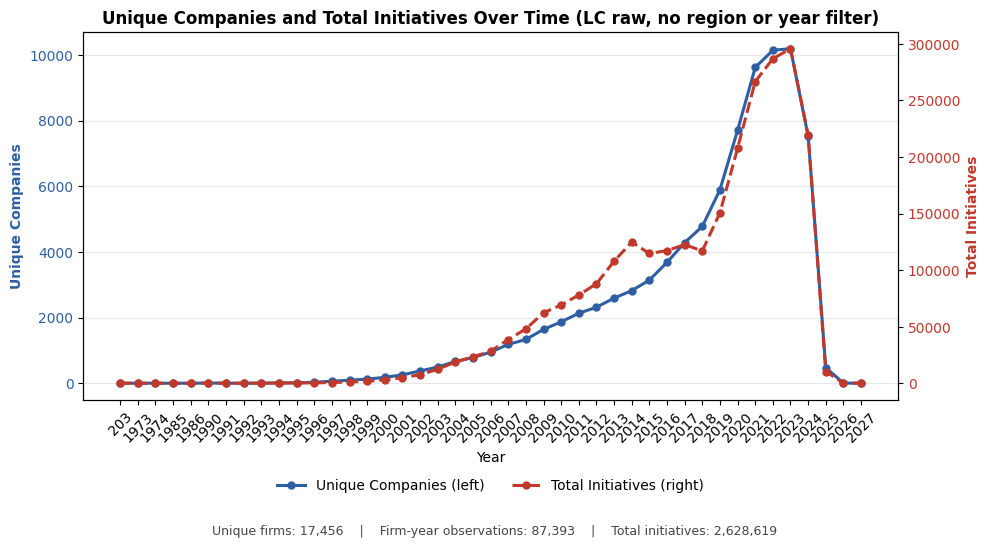

,unique_companies,firm_year_observations,total_initiatives
rfyear,,,
203,1,1,63
1973,1,1,2
1974,1,1,2
1985,1,1,3
1986,1,1,4
1990,6,6,98
1991,2,2,35
1992,2,2,30
1993,3,3,45


,unique_gvkeys,gvkey_year_obs,total_initiatives
fig1_firms_and_initiatives,17456,87393,2628619


In [5]:
# --- The Golden LC file as delivered: all regions, all years, no filters ---
# Only fig1 is produced here: it needs just rfyear / gvkey / n_predicted_initiatives,
# whereas the two share plots need the signal columns, which are built on the filtered
# `lc` further up.
import importlib
import descriptive_plots
importlib.reload(descriptive_plots)
from descriptive_plots import (
    plot_firms_and_initiatives,
    plot_signal_shares_over_time,
    plot_signal_shares_by_sector,
    sample_descriptives,
)

OUT_R = Path("outputs") / "LC_Raw_No_Region_Or_Year_Filter"
OUT_R.mkdir(parents=True, exist_ok=True)

# DATA QUALITY: rfyear is not clean in the unfiltered file. It holds a literal 203, a
# handful of pre-1990 years, and 2025-2027 records that post-date the sample. They are
# left in (that is what "no year filter" means) but listed here so the long left tail
# of the chart is not mistaken for real coverage.
_yr = lc_raw["rfyear"].value_counts().sort_index()
out_of_range = _yr[(_yr.index < 1990) | (_yr.index > end_year)]
print(f"rfyear spans {lc_raw['rfyear'].min()} to {lc_raw['rfyear'].max()} "
      f"across {lc_raw['rfyear'].nunique()} distinct values")
print(f"rows outside 1990-{end_year}: {int(out_of_range.sum())}")
display(out_of_range.rename("rows").to_frame())

fig1r, firms_initiatives_raw, desc1r = plot_firms_and_initiatives(
    lc_raw,
    title="Unique Companies and Total Initiatives Over Time (LC raw, no region or year filter)",
    save_path=OUT_R / "fig1_firms_and_initiatives_raw.png",
    excel_path=OUT_R / "fig1_firms_and_initiatives_raw.xlsx",
)

descriptives_raw = pd.concat(
    [desc1r], keys=["fig1_firms_and_initiatives"]
).droplevel(1)

display(firms_initiatives_raw)
display(descriptives_raw)

Analyse the Trends

[plot] saved outputs/LC_USA_No_Filter/fig1_firms_and_initiatives.png
[data] saved outputs/LC_USA_No_Filter/fig1_firms_and_initiatives.xlsx


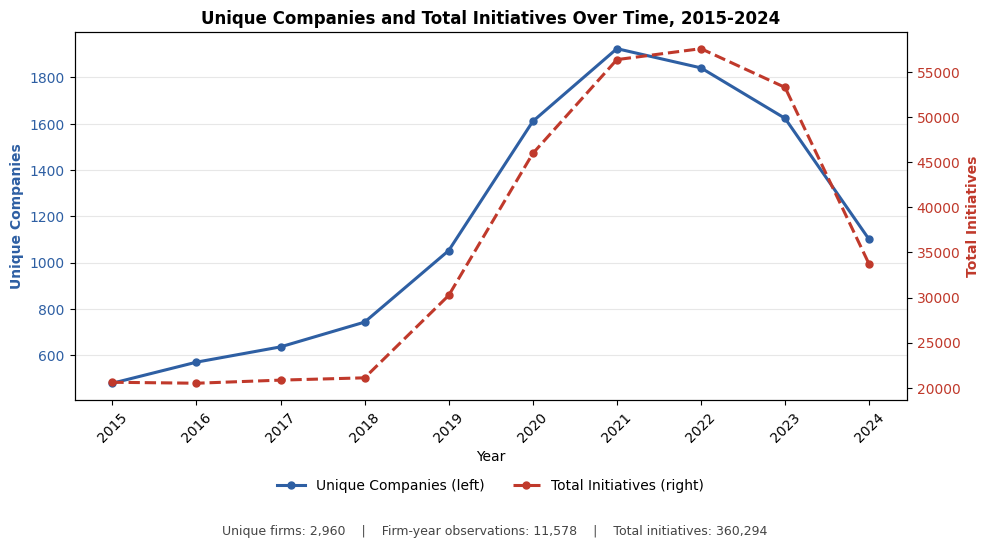

[plot] saved outputs/LC_USA_No_Filter/fig2_signal_shares_over_time.png
[data] saved outputs/LC_USA_No_Filter/fig2_signal_shares_over_time.xlsx


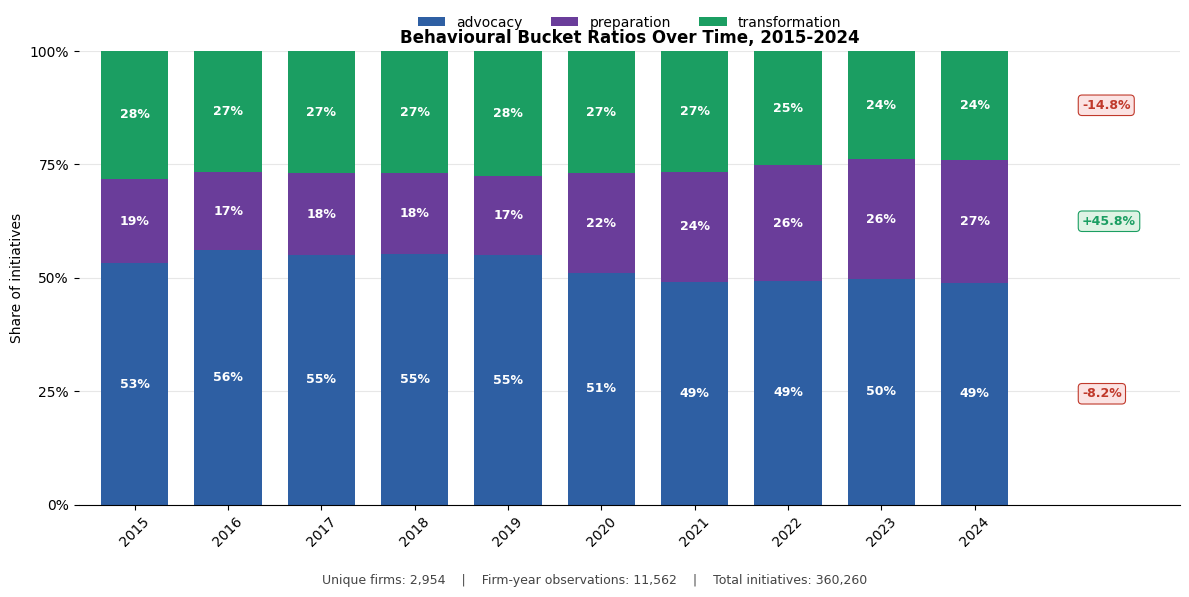

[plot] saved outputs/LC_USA_No_Filter/fig3_signal_shares_by_sector.png
[data] saved outputs/LC_USA_No_Filter/fig3_signal_shares_by_sector.xlsx


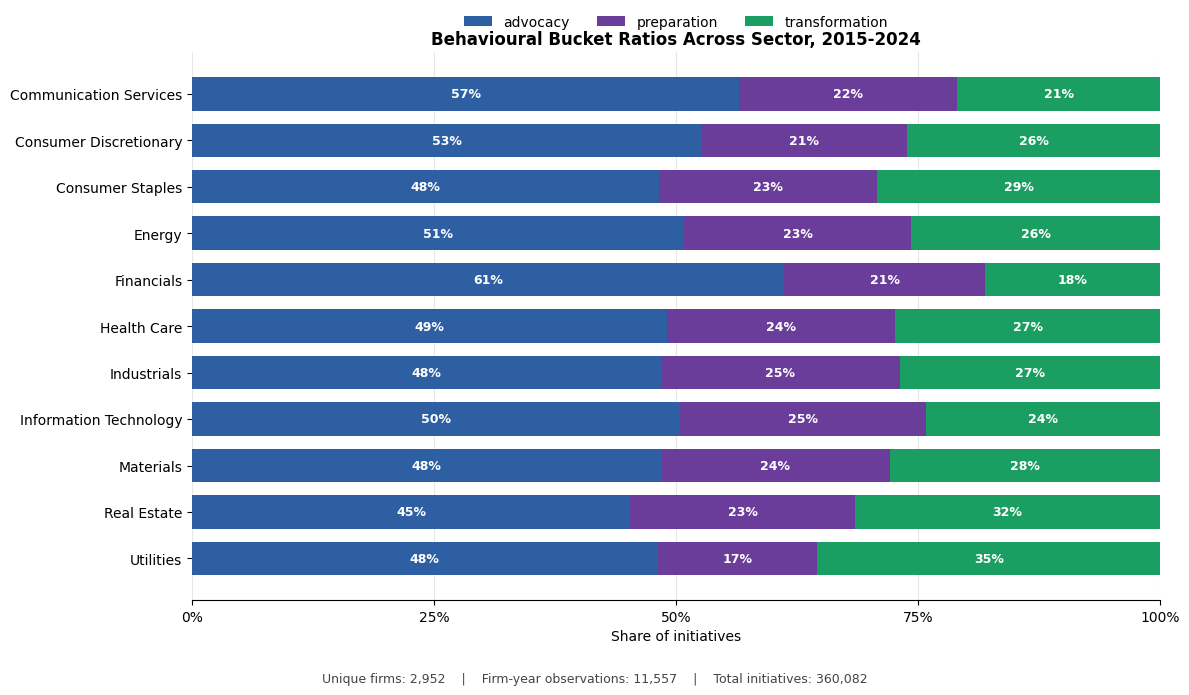

,unique_companies,firm_year_observations,total_initiatives
rfyear,,,
2015,479,479,20596
2016,570,570,20489
2017,636,636,20834
2018,743,743,21088
2019,1052,1052,30236
2020,1610,1610,45989
2021,1924,1924,56408
2022,1841,1841,57625
2023,1623,1623,53324


,advocacy,preparation,transformation
rfyear,,,
2015,53.2,18.6,28.1
2016,56.1,17.1,26.8
2017,55.1,17.9,27.0
2018,55.2,17.8,27.0
2019,54.9,17.4,27.6
2020,51.1,22.0,26.9
2021,49.2,24.2,26.6
2022,49.3,25.6,25.1
2023,49.8,26.4,23.9


,advocacy,preparation,transformation,n_obs
GICS_level_1,,,,
Utilities,48.0,16.5,35.4,638
Real Estate,45.3,23.2,31.5,771
Materials,48.5,23.6,28.0,822
Information Technology,50.4,25.3,24.2,1387
Industrials,48.4,24.7,26.9,1926
Health Care,49.1,23.6,27.4,1171
Financials,61.2,20.7,18.1,1720
Energy,50.9,23.4,25.7,709
Consumer Staples,48.3,22.5,29.2,684


,unique_gvkeys,gvkey_year_obs,total_initiatives
fig1_firms_and_initiatives,2960,11578,360294
fig2_signal_shares_over_time,2954,11562,360260
fig3_signal_shares_by_sector,2952,11557,360082


In [6]:
# --- Descriptive plots (functions live in descriptive_plots.py) ---
import importlib
import descriptive_plots
importlib.reload(descriptive_plots)   # pick up edits without restarting the kernel
from descriptive_plots import (
    plot_firms_and_initiatives,
    plot_signal_shares_over_time,
    plot_signal_shares_by_sector,
)

OUT = Path("outputs") / "LC_USA_No_Filter"   # full LC sample (no filtering)
OUT.mkdir(parents=True, exist_ok=True)

# Each plot returns (fig, data, descriptives). `descriptives` counts the rows THAT PLOT
# actually used, so fig2/fig3 come out below fig1: fig2 drops firm-years with no signal
# (sum_activities == 0 -> 0/0), fig3 additionally drops those with no GICS sector.

# 1) Firm-year observations / unique companies + total initiatives over time
fig1, firms_initiatives, desc1 = plot_firms_and_initiatives(
    lc,
    title=f"Unique Companies and Total Initiatives Over Time, {start_year}-{end_year}",
    save_path=OUT / "fig1_firms_and_initiatives.png",
    excel_path=OUT / "fig1_firms_and_initiatives.xlsx",
)

# 2) Average behavioural-bucket shares over time (advocacy / preparation / transformation)
fig2, shares_over_time, desc2 = plot_signal_shares_over_time(
    lc, signal_names,
    title=f"Behavioural Bucket Ratios Over Time, {start_year}-{end_year}",
    save_path=OUT / "fig2_signal_shares_over_time.png",
    excel_path=OUT / "fig2_signal_shares_over_time.xlsx",
)

# 3) Average behavioural-bucket shares by sector
fig3, shares_by_sector, desc3 = plot_signal_shares_by_sector(
    lc, signal_names,
    sector_col="GICS_level_1",
    title=f"Behavioural Bucket Ratios Across Sector, {start_year}-{end_year}",
    save_path=OUT / "fig3_signal_shares_by_sector.png",
    excel_path=OUT / "fig3_signal_shares_by_sector.xlsx",
)

# Sample behind each figure: unique gvkeys / unique gvkey-year obs / total initiatives.
descriptives_no_filter = pd.concat(
    [desc1, desc2, desc3],
    keys=[
        "fig1_firms_and_initiatives",
        "fig2_signal_shares_over_time",
        "fig3_signal_shares_by_sector",
    ],
).droplevel(1)

display(firms_initiatives)
display(shares_over_time.round(1))
display(shares_by_sector.round(1))
display(descriptives_no_filter)

Analyse the Trends - LC ∩ Compustat (matched sample)

[plot] saved outputs/LC_USA_Compustat_Matched/fig1_firms_and_initiatives_matched.png
[data] saved outputs/LC_USA_Compustat_Matched/fig1_firms_and_initiatives_matched.xlsx


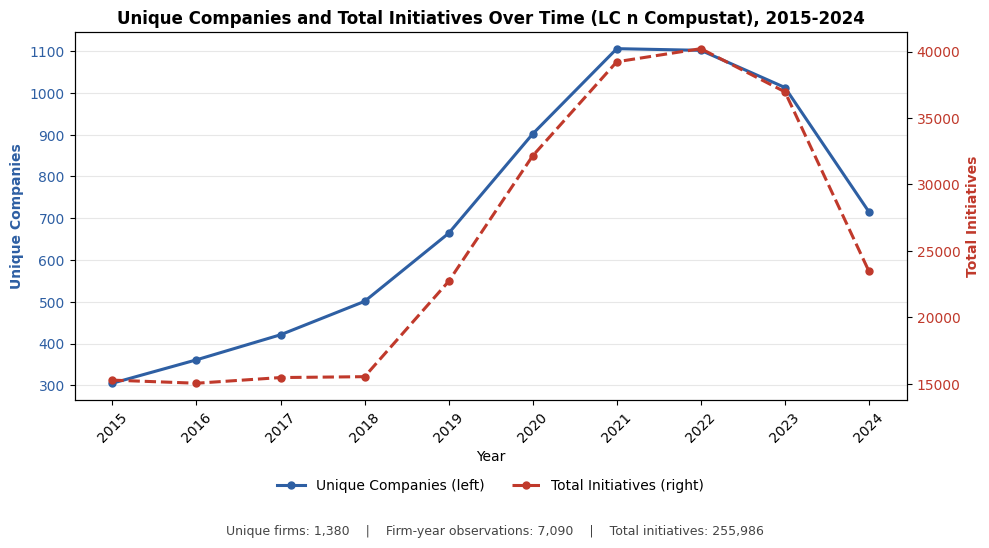

[plot] saved outputs/LC_USA_Compustat_Matched/fig2_signal_shares_over_time_matched.png
[data] saved outputs/LC_USA_Compustat_Matched/fig2_signal_shares_over_time_matched.xlsx


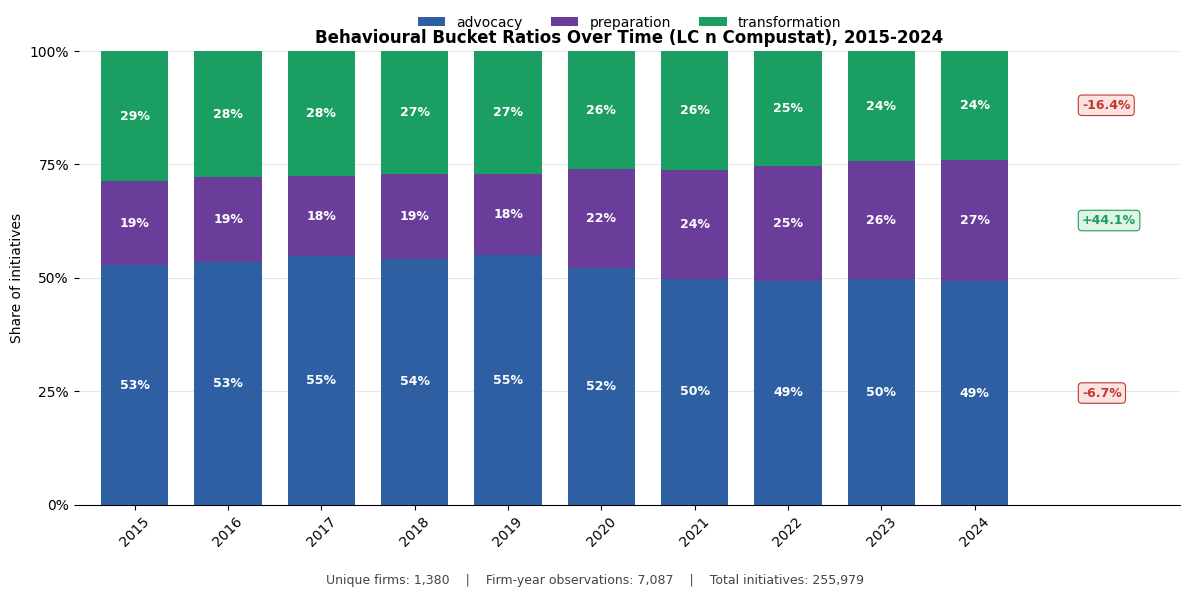

[plot] saved outputs/LC_USA_Compustat_Matched/fig3_signal_shares_by_sector_matched.png
[data] saved outputs/LC_USA_Compustat_Matched/fig3_signal_shares_by_sector_matched.xlsx


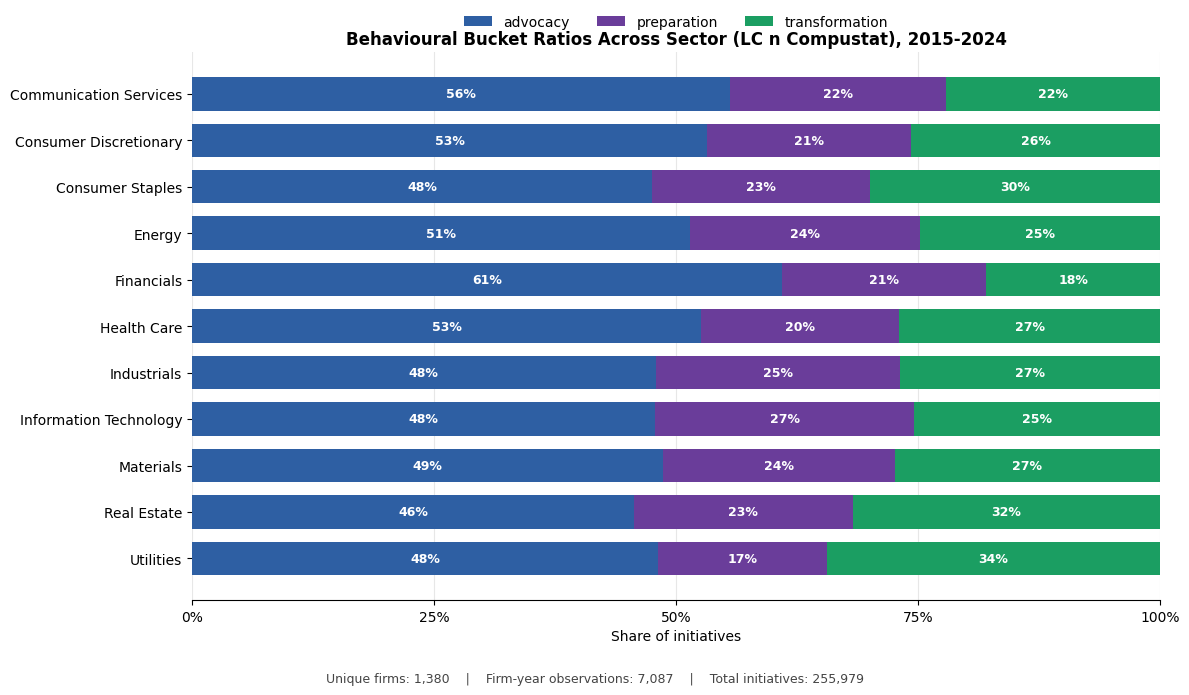

,unique_companies,firm_year_observations,total_initiatives
rfyear,,,
2015,305,305,15262
2016,361,361,15029
2017,421,421,15456
2018,501,501,15522
2019,664,664,22699
2020,902,902,32153
2021,1106,1106,39233
2022,1102,1102,40219
2023,1013,1013,36966


,advocacy,preparation,transformation
rfyear,,,
2015,52.7,18.6,28.6
2016,53.4,18.7,27.8
2017,54.8,17.7,27.5
2018,54.2,18.6,27.2
2019,55.0,17.9,27.0
2020,52.3,21.7,26.1
2021,49.8,23.9,26.3
2022,49.3,25.3,25.4
2023,49.7,26.0,24.3


,advocacy,preparation,transformation,n_obs
GICS_level_1,,,,
Utilities,48.2,17.4,34.4,437
Real Estate,45.6,22.6,31.8,660
Materials,48.6,23.9,27.4,580
Information Technology,47.8,26.8,25.4,519
Industrials,47.9,25.3,26.9,1282
Health Care,52.6,20.4,27.0,456
Financials,60.9,21.1,18.0,1253
Energy,51.4,23.8,24.8,446
Consumer Staples,47.5,22.5,30.0,446


,unique_gvkeys,gvkey_year_obs,total_initiatives
fig1_firms_and_initiatives,1380,7090,255986
fig2_signal_shares_over_time,1380,7087,255979
fig3_signal_shares_by_sector,1380,7087,255979


In [7]:
# --- Same three plots, restricted to the LC <-> Compustat intersection ---
OUT_M = Path("outputs") / "LC_USA_Compustat_Matched"   # LC n Compustat sample
OUT_M.mkdir(parents=True, exist_ok=True)

fig1m, firms_initiatives_matched, desc1m = plot_firms_and_initiatives(
    lc_merged,
    title=f"Unique Companies and Total Initiatives Over Time (LC n Compustat), {start_year}-{end_year}",
    save_path=OUT_M / "fig1_firms_and_initiatives_matched.png",
    excel_path=OUT_M / "fig1_firms_and_initiatives_matched.xlsx",
)

fig2m, shares_over_time_matched, desc2m = plot_signal_shares_over_time(
    lc_merged, signal_names,
    title=f"Behavioural Bucket Ratios Over Time (LC n Compustat), {start_year}-{end_year}",
    save_path=OUT_M / "fig2_signal_shares_over_time_matched.png",
    excel_path=OUT_M / "fig2_signal_shares_over_time_matched.xlsx",
)

fig3m, shares_by_sector_matched, desc3m = plot_signal_shares_by_sector(
    lc_merged, signal_names,
    sector_col="GICS_level_1",
    title=f"Behavioural Bucket Ratios Across Sector (LC n Compustat), {start_year}-{end_year}",
    save_path=OUT_M / "fig3_signal_shares_by_sector_matched.png",
    excel_path=OUT_M / "fig3_signal_shares_by_sector_matched.xlsx",
)

# Sample behind each figure: unique gvkeys / unique gvkey-year obs / total initiatives.
descriptives_matched = pd.concat(
    [desc1m, desc2m, desc3m],
    keys=[
        "fig1_firms_and_initiatives",
        "fig2_signal_shares_over_time",
        "fig3_signal_shares_by_sector",
    ],
).droplevel(1)

display(firms_initiatives_matched)
display(shares_over_time_matched.round(1))
display(shares_by_sector_matched.round(1))
display(descriptives_matched)

Sample Descriptives — No Filter vs LC ∩ Compustat

In [8]:
# --- All three populations side by side, per figure ---
# unique_gvkeys / gvkey_year_obs / total_initiatives for the sample behind each figure.
# Ordered broadest -> narrowest. The raw population has fig1 only (the share plots need
# signal columns, which are built on the filtered sample).
comparison = (
    pd.concat(
        [
            descriptives_raw.assign(population="1_LC_Raw_No_Region_Or_Year_Filter"),
            descriptives_no_filter.assign(population="2_LC_USA_No_Filter"),
            descriptives_matched.assign(population="3_LC_USA_Compustat_Matched"),
        ]
    )
    .reset_index(names="figure")
    .set_index(["population", "figure"])
)
display(comparison)

# What each successive narrowing costs, measured on fig1 (the only figure all three share).
funnel = pd.concat(
    [descriptives_raw, descriptives_no_filter.loc[["fig1_firms_and_initiatives"]],
     descriptives_matched.loc[["fig1_firms_and_initiatives"]]],
    keys=["1_raw", "2_usa_years", "3_compustat_matched"],
).droplevel(1)
funnel_pct = (funnel / funnel.iloc[0] * 100.0).round(1)
funnel_pct.columns = [f"{c}_pct_of_raw" for c in funnel_pct.columns]
display(funnel.join(funnel_pct))

comparison.to_excel(Path("outputs") / "sample_descriptives_comparison.xlsx")
print("[data] saved", Path("outputs") / "sample_descriptives_comparison.xlsx")

unique_gvkeys  \
population                        figure                                        
1_LC_Raw_No_Region_Or_Year_Filter fig1_firms_and_initiatives            17456   
2_LC_USA_No_Filter                fig1_firms_and_initiatives             2960   
                                  fig2_signal_shares_over_time           2954   
                                  fig3_signal_shares_by_sector           2952   
3_LC_USA_Compustat_Matched        fig1_firms_and_initiatives             1380   
                                  fig2_signal_shares_over_time           1380   
                                  fig3_signal_shares_by_sector           1380   

                                                                gvkey_year_obs  \
population                        figure                                         
1_LC_Raw_No_Region_Or_Year_Filter fig1_firms_and_initiatives             87393   
2_LC_USA_No_Filter                fig1_firms_and_initiatives             11578   
                                  fig2_signal_shares_over_time           11562   
                                  fig3_signal_shares_by_sector           11557   
3_LC_USA_Compustat_Matched        fig1_firms_and_initiatives              7090   
                                  fig2_signal_shares_over_time            7087   
                                  fig3_signal_shares_by_sector            7087   

                                                                total_initiatives  
population                        figure                                           
1_LC_Raw_No_Region_Or_Year_Filter fig1_firms_and_initiatives              2628619  
2_LC_USA_No_Filter                fig1_firms_and_initiatives               360294  
                                  fig2_signal_shares_over_time             360260  
                                  fig3_signal_shares_by_sector             360082  
3_LC_USA_Compustat_Matched        fig1_firms_and_initiatives               255986  
                                  fig2_signal_shares_over_time             255979  
                                  fig3_signal_shares_by_sector             255979

,unique_gvkeys,gvkey_year_obs,total_initiatives,unique_gvkeys_pct_of_raw,gvkey_year_obs_pct_of_raw,total_initiatives_pct_of_raw
1_raw,17456,87393,2628619,100.0,100.0,100.0
2_usa_years,2960,11578,360294,17.0,13.2,13.7
3_compustat_matched,1380,7090,255986,7.9,8.1,9.7


[data] saved outputs/sample_descriptives_comparison.xlsx
